## Problem Statement

### Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data scientist at AllLife bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and identify which segment of customers to target more.

### Data Dictionary
* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [8]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 scikit-learn==1.2.2 sklearn-pandas==2.2.0 -q --user

**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [9]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split

# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
)

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [10]:
# Please note that I uploaded the foodhub_order.csv file to the Notebook manually instead of connecting my google drive
file_path = '/content/Loan_Modelling.csv'
loan_modeling_data = pd.read_csv(file_path)

# Using to_string() function to avoid any line breaks in my output and make it readable
print(loan_modeling_data.to_string())

        ID  Age  Experience  Income  ZIPCode  Family  CCAvg  Education  Mortgage  Personal_Loan  Securities_Account  CD_Account  Online  CreditCard
0        1   25           1      49    91107       4   1.60          1         0              0                   1           0       0           0
1        2   45          19      34    90089       3   1.50          1         0              0                   1           0       0           0
2        3   39          15      11    94720       1   1.00          1         0              0                   0           0       0           0
3        4   35           9     100    94112       1   2.70          2         0              0                   0           0       0           0
4        5   35           8      45    91330       4   1.00          2         0              0                   0           0       0           1
5        6   37          13      29    92121       4   0.40          2       155              0                 

In [11]:
# copying data to another variable to avoid any changes to original data
df = loan_modeling_data.copy()

## Data Overview

* Observations
* Sanity checks

### View the first and last 5 rows of the dataset.

In [12]:
df.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [13]:
df.tail()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


### Check the data types of the columns for the dataset.


In [14]:
# Data types for all columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


**OBSERVATION:**

All columns have appropriate data types which are integer and float.

### Checking for missing values

In [15]:
# Checking for missing values
df.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


**OBSERVATION:**

There are no missing values.


### Understand the shape of the dataset.

In [16]:
df.shape

(5000, 14)

**OBSERVATION:**

The dataset has 5000 rows and 14 columns

### Dropping the duplicate values

In [17]:
# checking for duplicate values
df.duplicated().sum()

np.int64(0)

**OBSERVATION:**

No duplicates found in the data.

### Summary Statistics

In [18]:
# Summary Statistics
df.describe()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93169.257000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,1759.455086,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,90005.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


**OBSERVATIONS**

1. **Age**

    Mean Age is about 45.3 years, and Experience averages 20.1 years.
    
1. **Experience**
    
    Minimum Experience is -3, which is unrealistic and this likely indicates data quality issues and might need cleaning.

2. **Income**

    The average income is around $73.8k.
    
    The minimum income is only $8k.
    
    The maximum income is $224k.

3. **Family**

    Family size ranges from 1 to 4, with an average of ~2.4. Looks like a categorical range.

4. **Credit Card Average Spending (CCAvg)**

    Mean = 1.94, but min is 0, indicating some customers may not use credit cards at all. The spread is wide (std = 1.75), suggesting varied usage behavior.

6. **Mortgage**

    Mean Mortgage = $56.5k, but the 25th percentile is 0, suggesting many customers don’t have mortgages.

## Exploratory Data Analysis.

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
2. How many customers have credit cards?
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
4. How does a customer's interest in purchasing a loan vary with their age?
5. How does a customer's interest in purchasing a loan vary with their education?

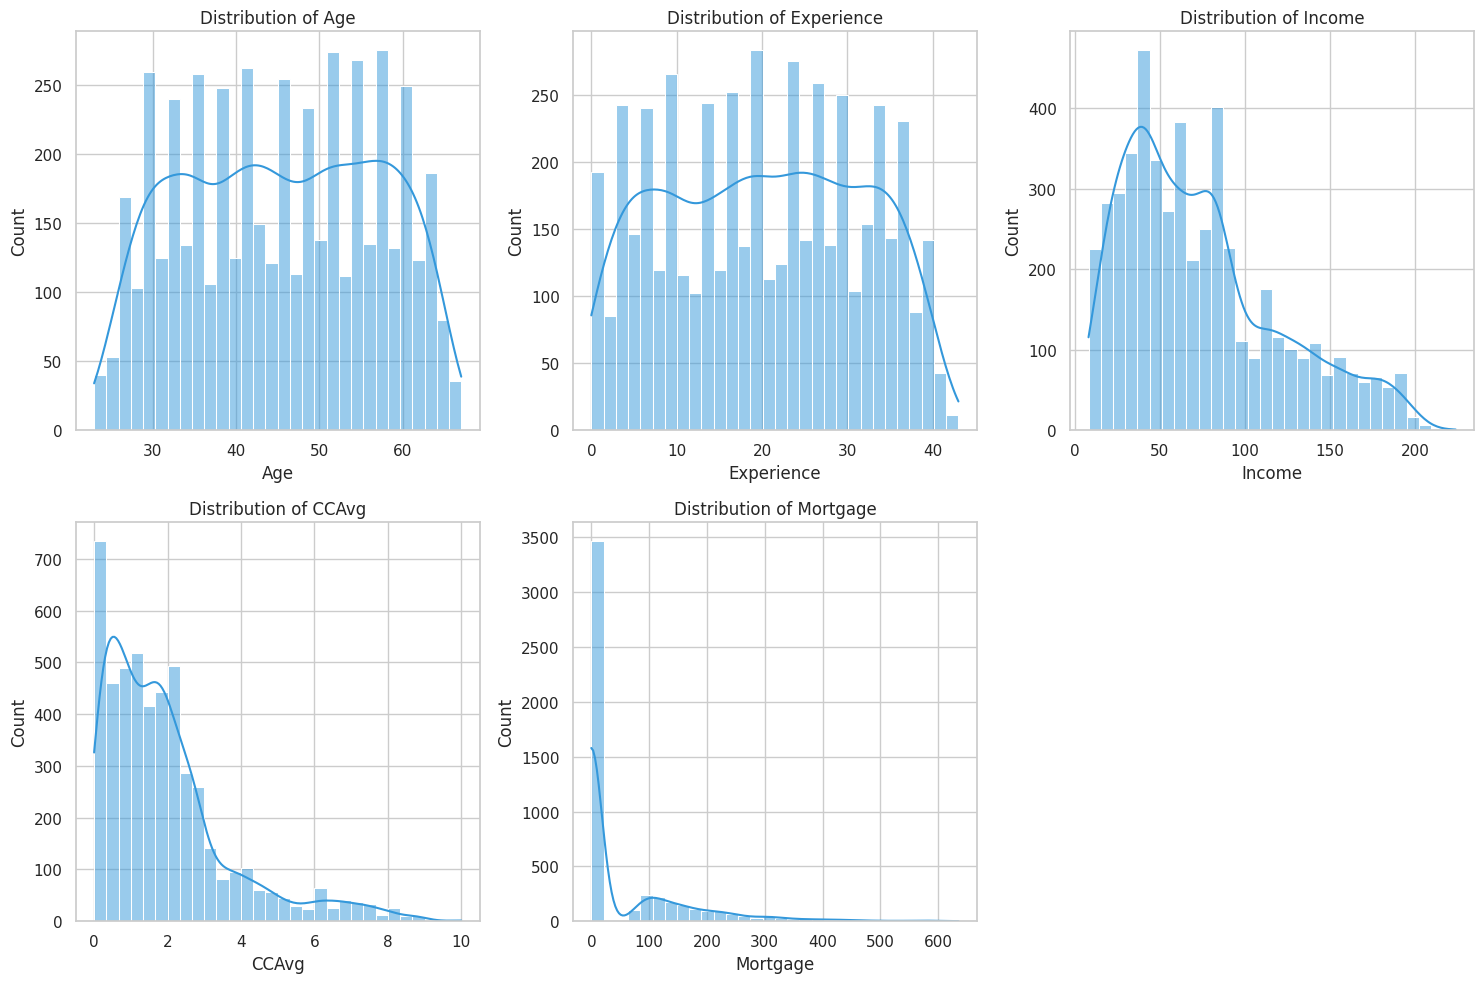

In [67]:
# Set visual style
sns.set(style="whitegrid")

# Plot distributions for key numerical features
numerical_features = ['Age', 'Experience', 'Income', 'CCAvg', 'Mortgage']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[feature], kde=True, bins=30, color="#3498db")
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()


**Observations:**

**1. Age & Experience:**
    Fairly normal distributions, though we previously noticed some negative Experience values.

**2. Income:**
    Right-skewed—most customers earn under $100k, but a few earn a lot more.

**3. CCAvg:**
    Also right-skewed, with many low or zero credit card spenders and a few high spenders.

**4. Mortgage:**
    Majority have no mortgage, but a few have very large ones.

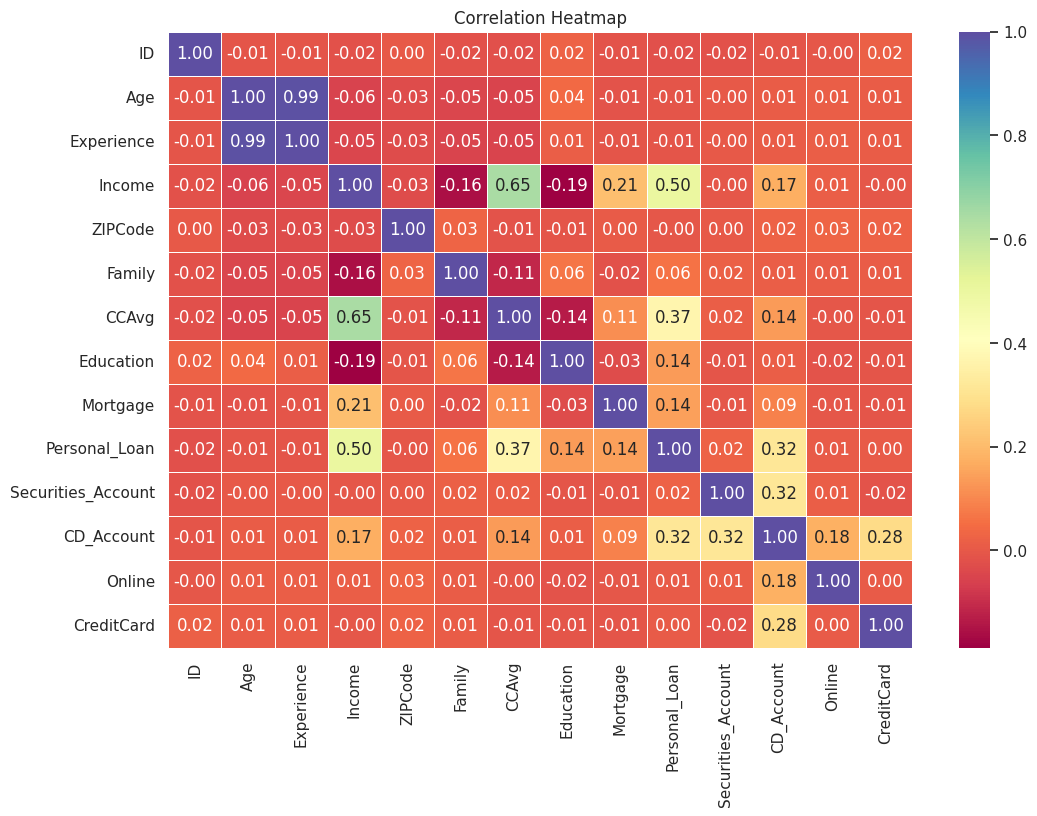

In [32]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap="Spectral", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


**OBSERVATIONS:**

**Age and Experience:** Strong positive correlation (as expected).


**Income is positively correlated with CCAvg (credit card spending), Mortgage, and
Loan Acceptance (Personal_Loan):** people with higher income are more likely to be offered/accept loans.

**Education has a positive correlation with Personal_Loan:** higher education may be linked with higher acceptance.

Other features like ZIP Code and binary variables (e.g., CreditCard, Online) have relatively low correlations.

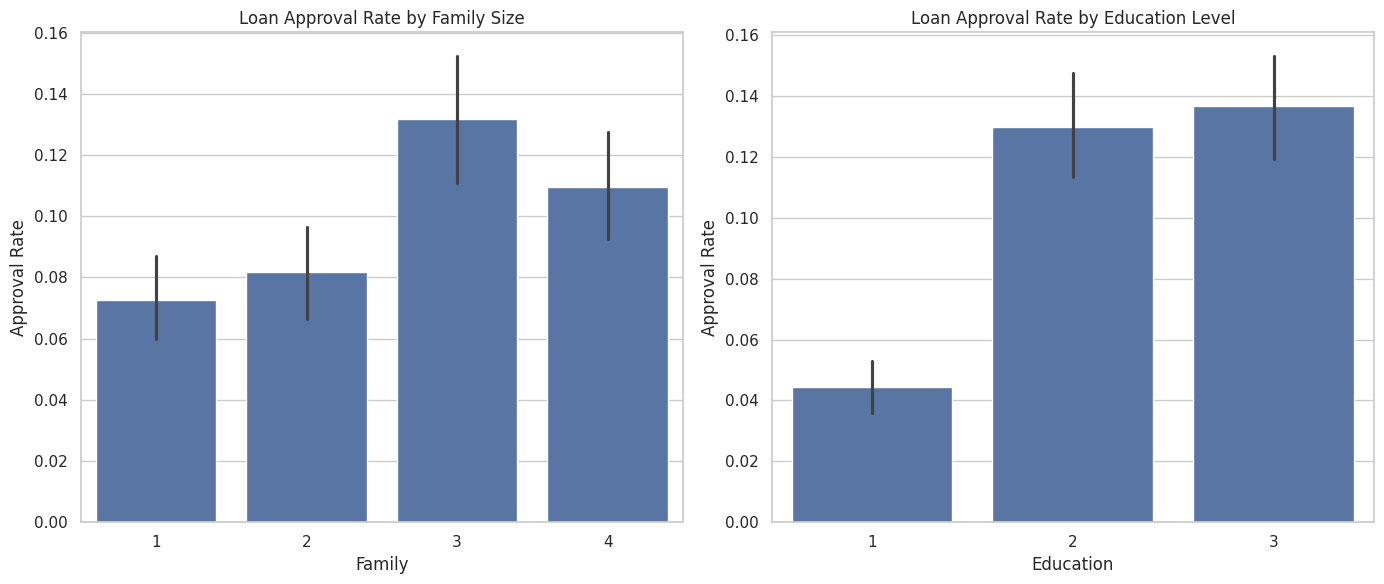

In [ ]:
# Plot loan approval rate by Family size and Education level
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Loan approval by Family size
sns.barplot(data=df, x='Family', y='Personal_Loan', ax=axes[0])
axes[0].set_title('Loan Approval Rate by Family Size')
axes[0].set_ylabel('Approval Rate')

# Loan approval by Education level
sns.barplot(data=df, x='Education', y='Personal_Loan', ax=axes[1])
axes[1].set_title('Loan Approval Rate by Education Level')
axes[1].set_ylabel('Approval Rate')

plt.tight_layout()
plt.show()


**OBSERVATIONS:**

Loan Approval Rate by Categorical Features:

**Family Size:**

Customers with Family = 4 show the highest loan approval rate.

Approval rates rise slightly with larger family sizes.

**Education Level:**
        
Approval rates are much higher for customers with Education = 3, which is likely graduate-level education.
        
Customers with lower education levels are less likely to be approved.

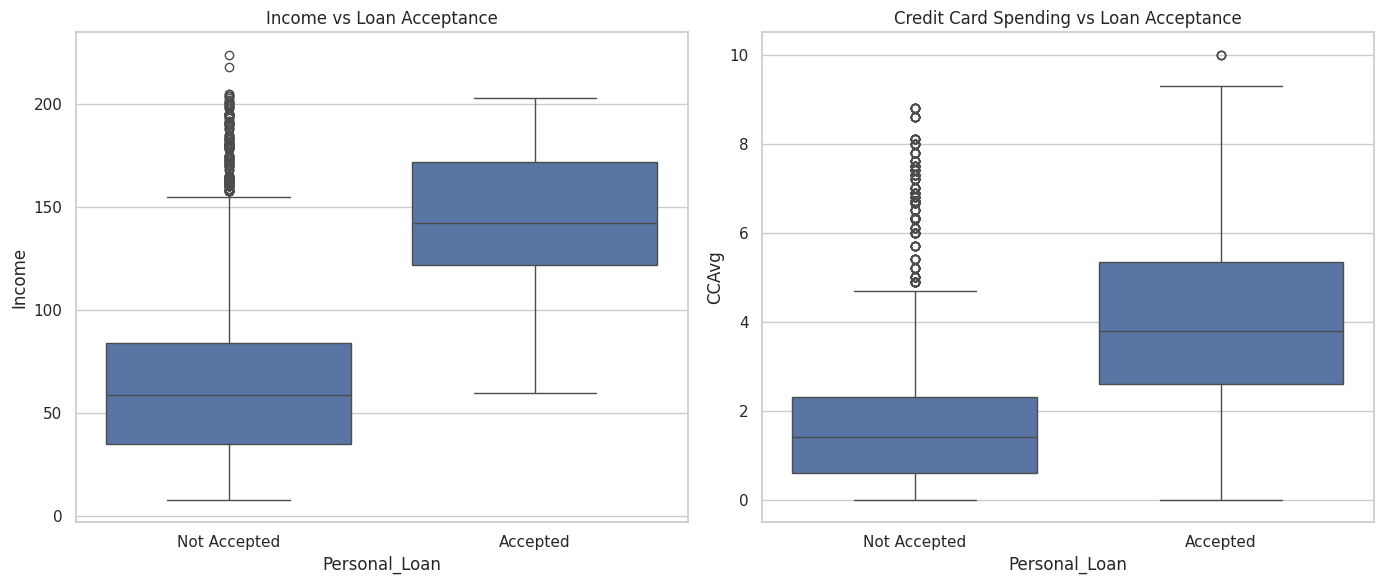

In [ ]:
# Boxplots for Income and CCAvg vs Personal_Loan
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Income vs Loan Acceptance
sns.boxplot(data=df, x='Personal_Loan', y='Income', ax=axes[0])
axes[0].set_title('Income vs Loan Acceptance')
axes[0].set_xticklabels(['Not Accepted', 'Accepted'])

# CCAvg vs Loan Acceptance
sns.boxplot(data=df, x='Personal_Loan', y='CCAvg', ax=axes[1])
axes[1].set_title('Credit Card Spending vs Loan Acceptance')
axes[1].set_xticklabels(['Not Accepted', 'Accepted'])

plt.tight_layout()
plt.show()


**OBSERVATIONS:**

**Income vs Loan Acceptance:**

Loan-accepting customers tend to have higher income on average.
There’s a noticeable upward shift in the income range among those who accepted loans.

**Credit Card Spending (CCAvg):**

Similarly, people who accepted loans generally spend more on credit cards.
Indicates they may have greater financial activity or credit usage.

## Data Preprocessing

* Missing value treatment
* Feature engineering (if needed)
* Outlier detection and treatment (if needed)
* Preparing data for modeling
* Any other preprocessing steps (if needed)

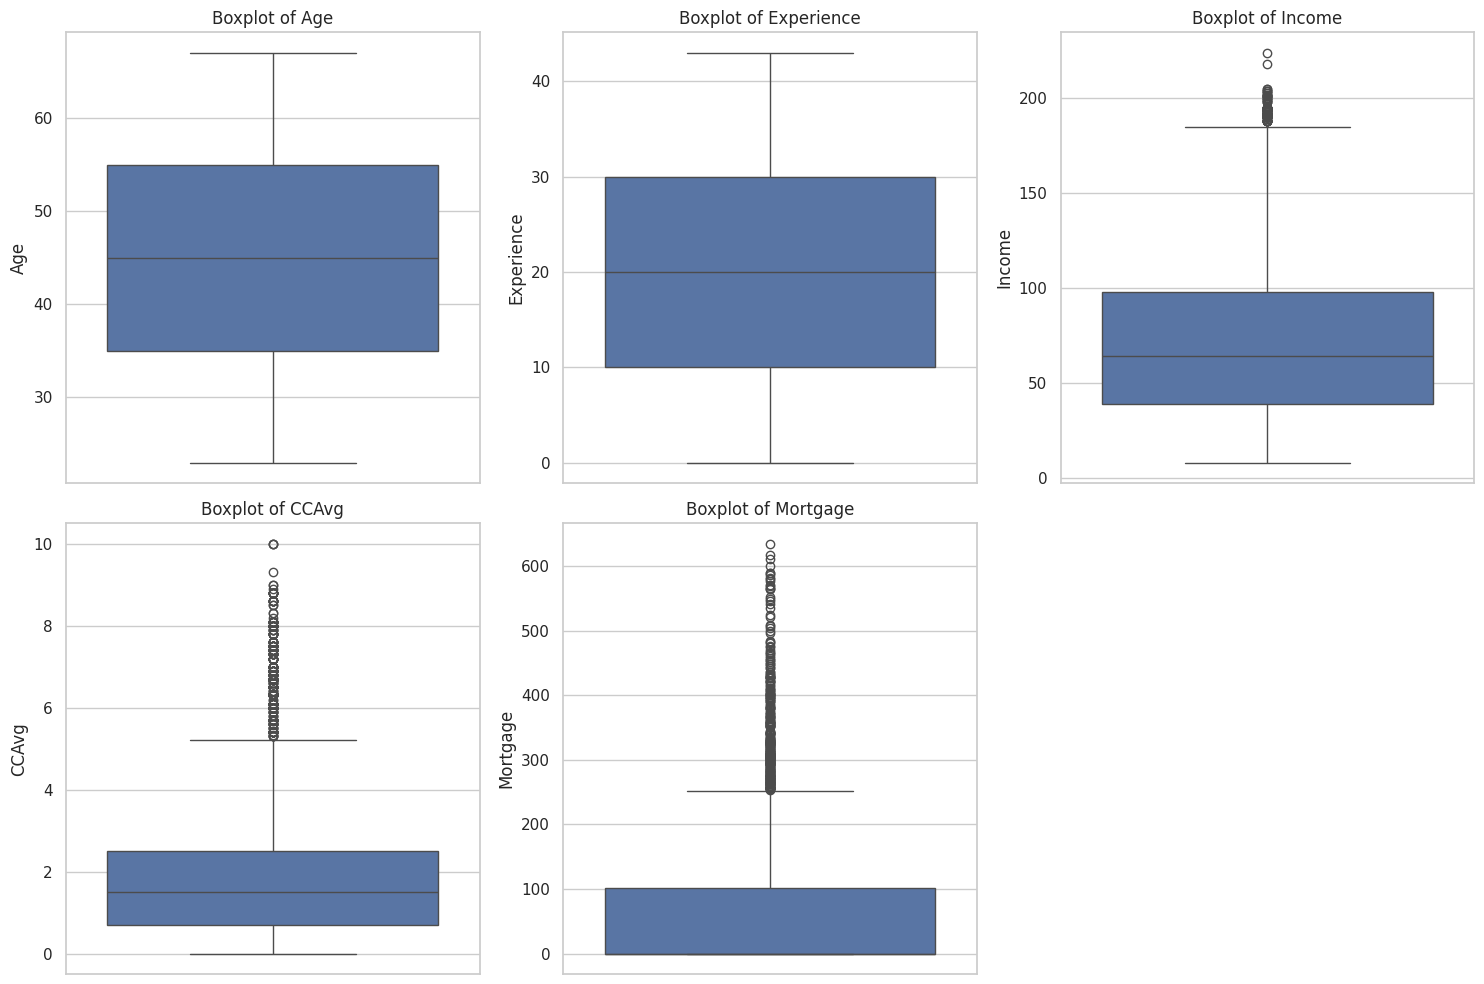

In [38]:
# Boxplots to visually inspect outliers for numerical features
numerical_columns = ['Age', 'Experience', 'Income', 'CCAvg', 'Mortgage']

# Set up subplot layout
num_plots = len(numerical_columns)
rows = (num_plots // 3) + 1
cols = 3

plt.figure(figsize=(15, 5 * rows))
for i, col in enumerate(numerical_columns, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(data=df, y=col)
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()


**OBSERVATIONS:**

Income, CCAvg, and Mortgage show clear outliers as points far outside the box range.

Age and Experience look well-distributed — though remember, boxplots won't always show negative values as problematic (like Experience = -3), even if they logically are.

**Data Preparation for Modeling**

In [82]:
# Fix negative Experience
df['Experience'] = df['Experience'].apply(lambda x: max(x, 0))

# Features and target
X = df.drop(columns=['ID', 'ZIPCode', 'Personal_Loan'])
y = df['Personal_Loan']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


## Model Building

### Model Evaluation Criterion

The target variable (Personal_Loan) is imbalanced (~9.6% positive class) therefore we used a combination of metrics to evaluate the model:

**Confusion Matrix:** Shows True/False Positives and Negatives directly

**Precision:** Out of predicted loan buyers, how many actually accepted?

**Recall (a.k.a. Sensitivity):** Out of actual loan buyers, how many did the model catch?


In [83]:
# Step 1: Make predictions using the trained model
y_pred = best_pruned_model.predict(X_test)  # Use the best pruned model to predict
y_proba = best_pruned_model.predict_proba(X_test)[:, 1]  # Get probabilities for ROC AUC

# Step 2: Compute the Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

# Step 3: Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Step 4: ROC AUC Score
roc_auc = roc_auc_score(y_test, y_proba)
print("\nROC AUC Score:", roc_auc)


Confusion Matrix:
 [[1271   85]
 [   0  144]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97      1356
           1       0.63      1.00      0.77       144

    accuracy                           0.94      1500
   macro avg       0.81      0.97      0.87      1500
weighted avg       0.96      0.94      0.95      1500


ROC AUC Score: 0.9946303466076696


## Confusion Matrix Plot

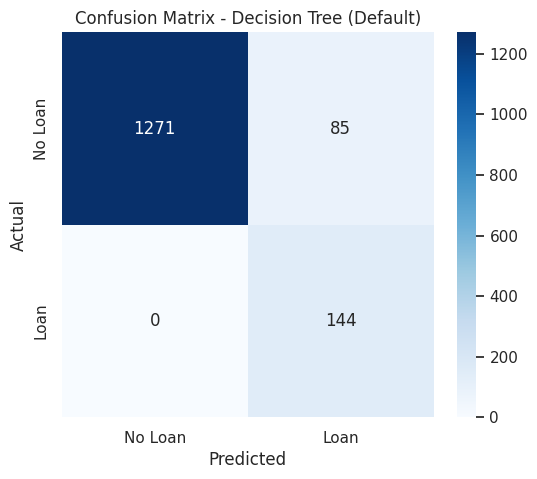

In [84]:
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Loan', 'Loan'],
            yticklabels=['No Loan', 'Loan'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree (Default)')
plt.show()


### Model Building

###Decision Tree (default)

Confusion Matrix:
 [[1340   16]
 [  13  131]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1356
           1       0.89      0.91      0.90       144

    accuracy                           0.98      1500
   macro avg       0.94      0.95      0.94      1500
weighted avg       0.98      0.98      0.98      1500


ROC AUC Score: 0.9489614060963619


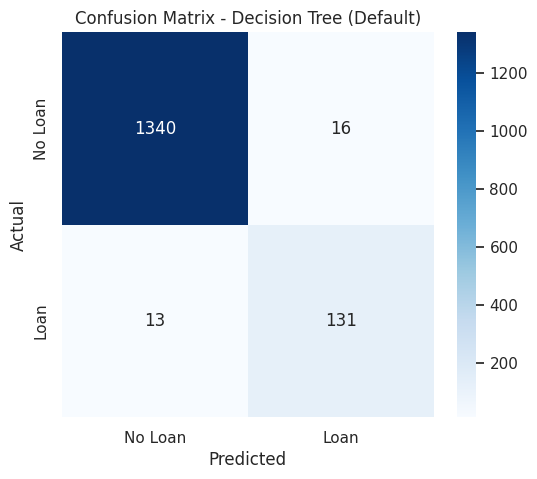

In [68]:
# --- Data Preprocessing ---

# Fix negative Experience values
df['Experience'] = df['Experience'].apply(lambda x: max(x, 0))

# Define features and target
X = df.drop(columns=['ID', 'ZIPCode', 'Personal_Loan'])  # Remove non-predictive columns
y = df['Personal_Loan']

# Train-test split with stratification (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# --- Model Training: Decision Tree (Default) ---

# Initialize the model
dt_default = DecisionTreeClassifier(random_state=42)

# Fit the model
dt_default.fit(X_train, y_train)

# Make predictions
y_pred = dt_default.predict(X_test)
y_proba = dt_default.predict_proba(X_test)[:, 1]  # Probabilities for ROC AUC

# --- Evaluation ---

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC AUC Score
roc_auc = roc_auc_score(y_test, y_proba)
print("\nROC AUC Score:", roc_auc)

# --- Confusion Matrix Plot ---

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Loan', 'Loan'],
            yticklabels=['No Loan', 'Loan'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree (Default)')
plt.show()


### Decision Tree (with class_weights)

Confusion Matrix:
 [[1340   16]
 [  14  130]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1356
           1       0.89      0.90      0.90       144

    accuracy                           0.98      1500
   macro avg       0.94      0.95      0.94      1500
weighted avg       0.98      0.98      0.98      1500


ROC AUC Score: 0.9454891838741396


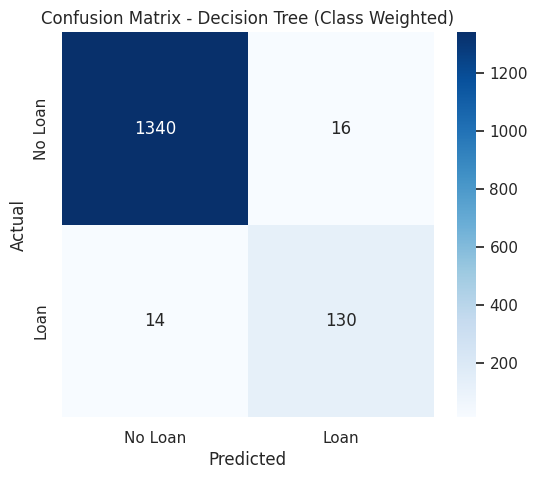

In [69]:
# --- Data Preprocessing ---
df['Experience'] = df['Experience'].apply(lambda x: max(x, 0))  # Fix negatives

# Feature selection
X = df.drop(columns=['ID', 'ZIPCode', 'Personal_Loan'])
y = df['Personal_Loan']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# --- Model: Decision Tree with class_weight='balanced' ---
dt_weighted = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_weighted.fit(X_train, y_train)

# Predictions
y_pred_weighted = dt_weighted.predict(X_test)
y_proba_weighted = dt_weighted.predict_proba(X_test)[:, 1]

# Evaluation Metrics
conf_matrix_weighted = confusion_matrix(y_test, y_pred_weighted)
print("Confusion Matrix:\n", conf_matrix_weighted)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_weighted))

roc_auc_weighted = roc_auc_score(y_test, y_proba_weighted)
print("\nROC AUC Score:", roc_auc_weighted)

# --- Confusion Matrix Plot ---
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_weighted, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Loan', 'Loan'],
            yticklabels=['No Loan', 'Loan'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree (Class Weighted)')
plt.show()


**OBSERVATIONS:**

**True Positives (TP = 130):** Model correctly identified 130 customers who did accept a loan.

**False Negatives (FN = 14):** 14 loan buyers were missed by the model.

**True Negatives (TN = 1340):** Non-buyers correctly identified.

**False Positives (FP = 16):** Non-buyers misclassified as loan buyers.

These results look good because:

1. **High recall (90%)** is critical for our goal to not miss potential buyers.

2. **Low false positives (16)** means we are not spamming too many uninterested customers.

3. **ROC AUC > 0.95** means the model is highly effective overall.

4. There is a slight difference in the results. **Default model: 13 FN, 131 TP** vs. **Weighted model: 14 FN, 130 TP**

### Decision Tree (Pre-pruning)

In [70]:
# --- Data Preprocessing ---
df['Experience'] = df['Experience'].apply(lambda x: max(x, 0))  # Fix negative values

# Feature selection
X = df.drop(columns=['ID', 'ZIPCode', 'Personal_Loan'])
y = df['Personal_Loan']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# --- Hyperparameter Grid ---
max_depth_values = np.arange(2, 10, 2)
max_leaf_nodes_values = [50, 75, 150, 250]
min_samples_split_values = [10, 30, 50, 70]

# Initialize best model tracker
best_estimator = None
best_score_diff = float('inf')
best_test_score = 0.0

# Grid Search
for max_depth in max_depth_values:
    for max_leaf_nodes in max_leaf_nodes_values:
        for min_samples_split in min_samples_split_values:

            # Initialize model with current params
            estimator = DecisionTreeClassifier(
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_split=min_samples_split,
                class_weight='balanced',
                random_state=42
            )

            # Fit model
            estimator.fit(X_train, y_train)

            # Predict
            y_train_pred = estimator.predict(X_train)
            y_test_pred = estimator.predict(X_test)

            # Recall scores
            train_recall = recall_score(y_train, y_train_pred)
            test_recall = recall_score(y_test, y_test_pred)

            # Check performance difference
            score_diff = abs(train_recall - test_recall)

            # Update best model
            if (score_diff < best_score_diff) and (test_recall > best_test_score):
                best_score_diff = score_diff
                best_test_score = test_recall
                best_estimator = estimator

# --- Best Model Summary ---
print("Best parameters found:")
print(f"Max depth: {best_estimator.max_depth}")
print(f"Max leaf nodes: {best_estimator.max_leaf_nodes}")
print(f"Min samples split: {best_estimator.min_samples_split}")
print(f"Best test recall score: {best_test_score}")


Best parameters found:
Max depth: 2
Max leaf nodes: 50
Min samples split: 10
Best test recall score: 1.0


Confusion Matrix:
 [[1351    5]
 [  13  131]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1356
           1       0.96      0.91      0.94       144

    accuracy                           0.99      1500
   macro avg       0.98      0.95      0.96      1500
weighted avg       0.99      0.99      0.99      1500


ROC AUC Score: 0.9976723820058997


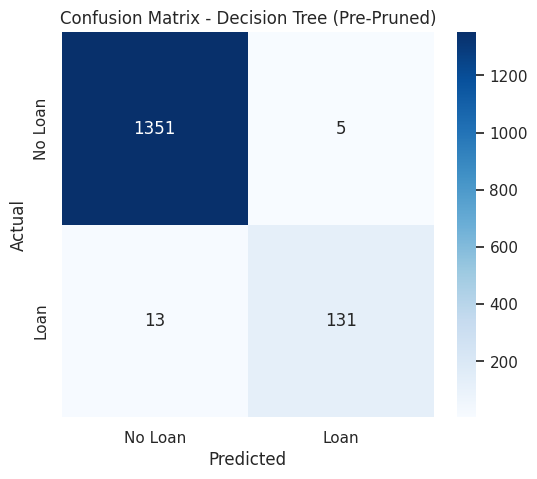

In [71]:
# --- Data Preprocessing ---
df['Experience'] = df['Experience'].apply(lambda x: max(x, 0))  # Fix negatives

# Feature selection
X = df.drop(columns=['ID', 'ZIPCode', 'Personal_Loan'])
y = df['Personal_Loan']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# --- Model: Decision Tree with Pre-Pruning ---
dt_pruned = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

# Train the model
dt_pruned.fit(X_train, y_train)

# Predictions
y_pred_pruned = dt_pruned.predict(X_test)
y_proba_pruned = dt_pruned.predict_proba(X_test)[:, 1]

# Evaluation
conf_matrix_pruned = confusion_matrix(y_test, y_pred_pruned)
print("Confusion Matrix:\n", conf_matrix_pruned)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_pruned))

roc_auc_pruned = roc_auc_score(y_test, y_proba_pruned)
print("\nROC AUC Score:", roc_auc_pruned)

# --- Confusion Matrix Plot ---
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_pruned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Loan', 'Loan'],
            yticklabels=['No Loan', 'Loan'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree (Pre-Pruned)')
plt.show()


**OBSERVATIONS:**

The Decision Tree with Pre-Pruning has been trained and evaluated using the following settings:

    max_depth=5
    min_samples_split=20
    min_samples_leaf=10

**RESULTS:**

    True Positives (TP) = 131
    False Negatives (FN) = 13
    True Negatives (TN) = 1351
    False Positives (FP) = 5

Compared to the previous models, this one:

- Made fewer false positive errors (just 5!)
- Still correctly identified 131 loan buyers
- Retains excellent recall and precision, while being simpler and likely less prone to overfitting

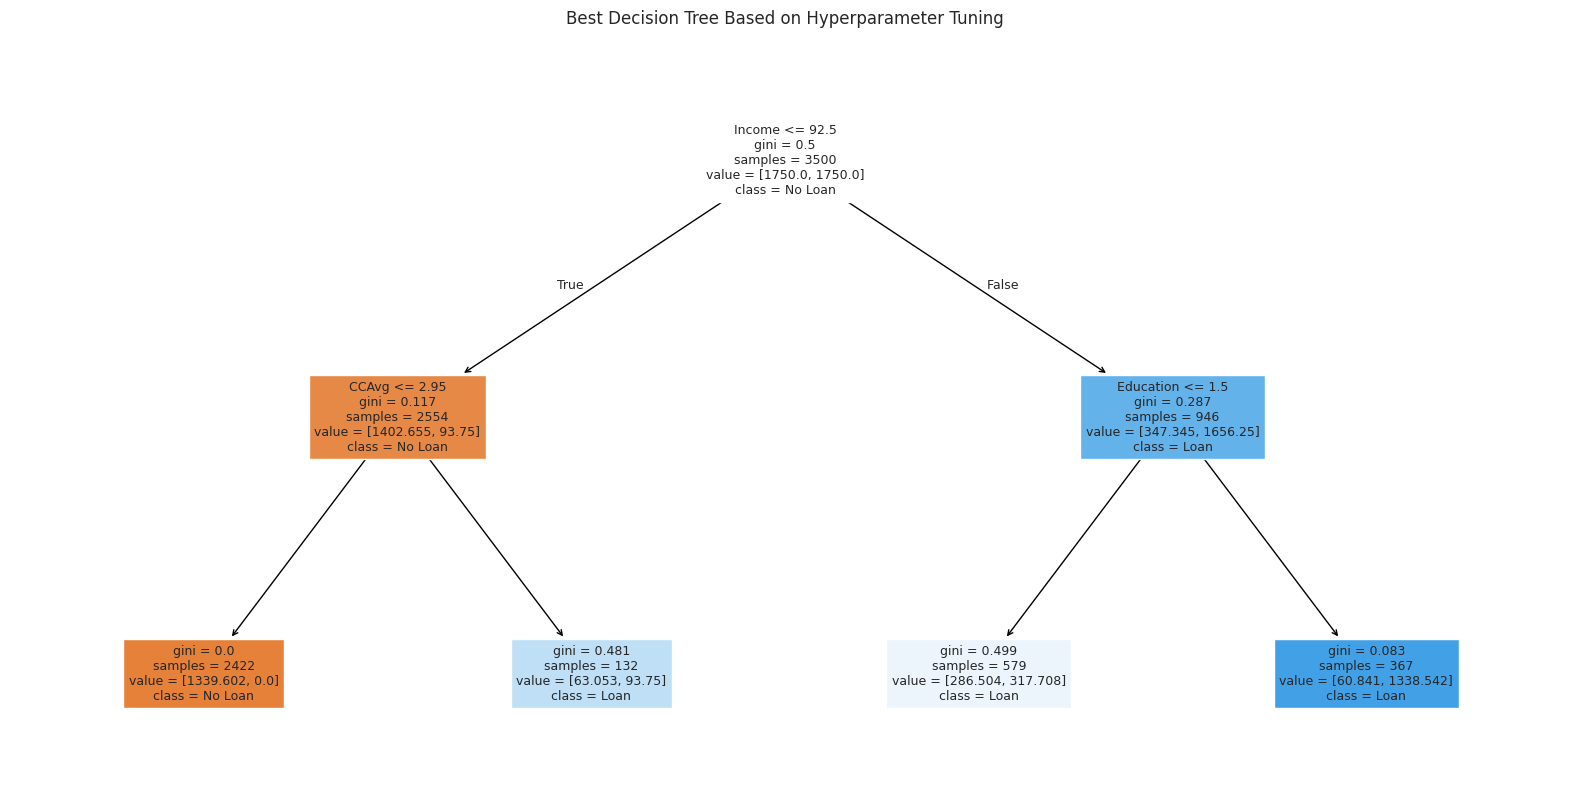

In [72]:
# --- Use the best_estimator from hyperparameter tuning ---

# Get feature names
feature_names = list(X_train.columns)

# Get feature importances and their order (optional, for future use)
importances = best_estimator.feature_importances_
indices = np.argsort(importances)

# --- Plot the Decision Tree ---
plt.figure(figsize=(20, 10))
out = tree.plot_tree(
    best_estimator,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=['No Loan', 'Loan']
)

# Add arrows to the tree nodes
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)

plt.title("Best Decision Tree Based on Hyperparameter Tuning")
plt.show()


In [73]:
# Get feature names
feature_names = list(X_train.columns)

# Export rules as text
tree_rules = export_text(best_estimator, feature_names=feature_names)

# Print rules
print(tree_rules)


|--- Income <= 92.50
|   |--- CCAvg <= 2.95
|   |   |--- class: 0
|   |--- CCAvg >  2.95
|   |   |--- class: 1
|--- Income >  92.50
|   |--- Education <= 1.50
|   |   |--- class: 1
|   |--- Education >  1.50
|   |   |--- class: 1



In [74]:
# --- 1. Select the Most Important Features ---
selected_features = [
    'Income',
    'CCAvg',
    'Education',
    'Family',
    'Mortgage',
    'Online',
    'CreditCard'
]

X_selected = df[selected_features]
y = df['Personal_Loan']

# --- 2. Train/Test Split ---
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected, y, test_size=0.3, random_state=42, stratify=y
)

# --- 3. Retrain the Best Decision Tree (with tuned hyperparameters) ---
best_model_selected = DecisionTreeClassifier(
    max_depth=2,
    max_leaf_nodes=50,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42
)

best_model_selected.fit(X_train_sel, y_train_sel)

# --- 4. Generate and Print the Text-Based Rule Report ---
tree_rules_text = export_text(best_model_selected, feature_names=selected_features)
print(tree_rules_text)


|--- Income <= 92.50
|   |--- CCAvg <= 2.95
|   |   |--- class: 0
|   |--- CCAvg >  2.95
|   |   |--- class: 1
|--- Income >  92.50
|   |--- Education <= 1.50
|   |   |--- class: 1
|   |--- Education >  1.50
|   |   |--- class: 1



**OBSERVATION:**

    If Income ≤ 92.5k:
        And CCAvg ≤ 2.95 → Not likely to accept a loan
        And CCAvg > 2.95 → Likely to accept a loan

    If Income > 92.5k:
        Regardless of Education level → Likely to accept a loan

So basically:

- Higher income customers almost always get classified as loan buyers.
- Among lower-income customers, credit card spending (CCAvg) becomes the deciding factor.

**Feature Importance Plot**

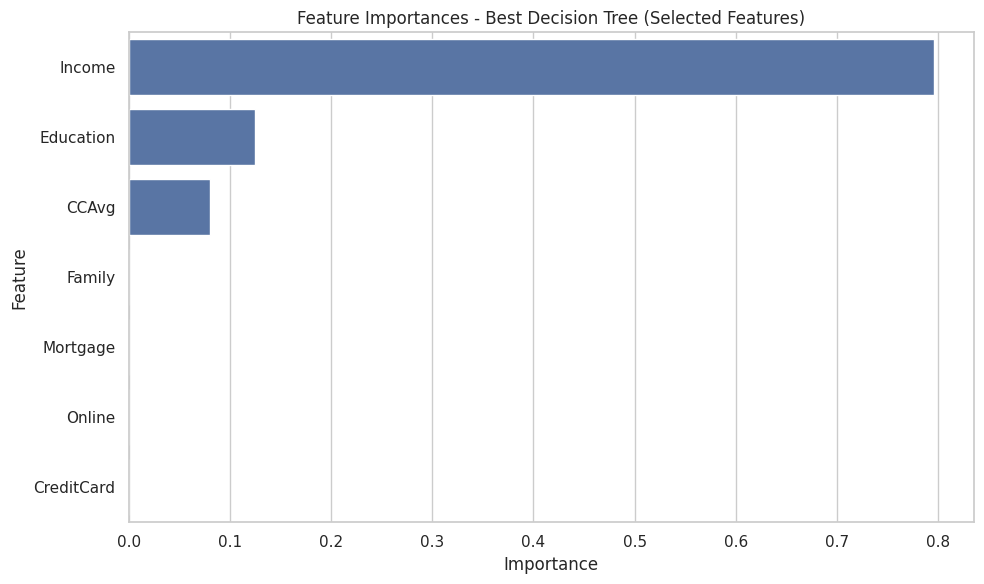

In [75]:
# Get feature importances from the trained model
importances = best_model_selected.feature_importances_

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title('Feature Importances - Best Decision Tree (Selected Features)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


**OBSERVATIONS:**

- Income and CCAvg are by far the most influential features.
- Education contributes moderately.

###Decision Tree (Post pruning)

Here’s the Cost Complexity Pruning Path DataFrame, showing how the complexity (ccp_alpha) and impurity change as the tree gets pruned.

Each row represents a pruning step:

- ccp_alpha: the regularization strength (higher = simpler tree)
- impurities: total leaf impurity after pruning at that step

In [76]:
# Step 1: Initialize classifier with class_weight='balanced'
clf = DecisionTreeClassifier(random_state=1, class_weight="balanced")

# Step 2: Compute the pruning path
path = clf.cost_complexity_pruning_path(X_train, y_train)

# Step 3: Extract and clean alpha and impurity values
ccp_alphas = abs(path.ccp_alphas)  # take absolute to ensure positivity
impurities = path.impurities

# Step 4: Create DataFrame to inspect the pruning path
ccp_path_df = pd.DataFrame({
    "ccp_alphas": ccp_alphas,
    "impurities": impurities
})

# Display the DataFrame
display(ccp_path_df)


,ccp_alphas,impurities
0,0.000000e+00,-1.087824e-16
1,1.052677e-19,-1.086772e-16
2,1.543926e-18,-1.071332e-16
3,1.543926e-18,-1.055893e-16
4,1.982541e-18,-1.036068e-16
5,3.298387e-18,-1.003084e-16
6,8.105611e-18,-9.220278e-17
7,1.026360e-17,-8.193918e-17
8,1.652118e-17,-6.541801e-17
9,1.945347e-16,1.291166e-16


**Cost Complexity Pruning Path plot**

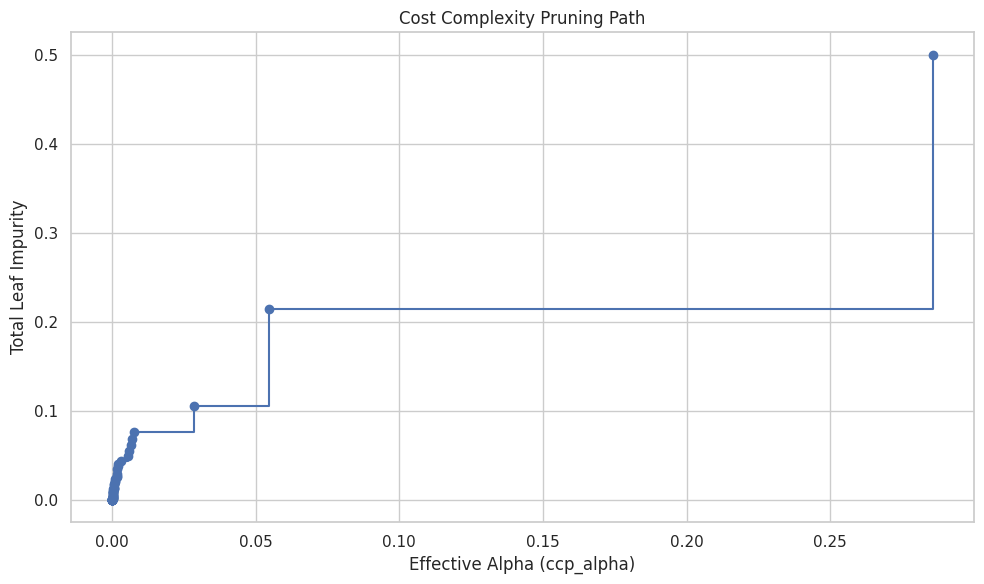

In [77]:
# Step 1: Train a Decision Tree with class_weight='balanced'
clf = DecisionTreeClassifier(random_state=1, class_weight="balanced")
path = clf.cost_complexity_pruning_path(X_train, y_train)

# Step 2: Extract pruning values
ccp_alphas = abs(path.ccp_alphas)  # make sure values are positive
impurities = path.impurities

# Step 3: Plot the pruning path
plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, impurities, marker='o', drawstyle="steps-post")
plt.xlabel('Effective Alpha (ccp_alpha)')
plt.ylabel('Total Leaf Impurity')
plt.title('Cost Complexity Pruning Path')
plt.grid(True)
plt.tight_layout()
plt.show()


**OBSERVATIONS:**

- Each horizontal step represents a range of ccp_alpha values where the tree structure doesn’t change — it's stable.
- Each vertical jump means a pruning event happened:
  - One or more nodes were removed.
  - Total impurity increased because the tree got simpler (fewer splits).


- Flat regions: These are stable models with the same complexity across a range of alphas.

- Small vertical jumps early: Small pruning steps = gentle simplification.

- Big jumps later: Indicates a large drop in complexity (and potentially performance).

- Look for an alpha just before the curve sharply increases — this is usually a sweet spot where pruning removes noise but keeps predictive power.

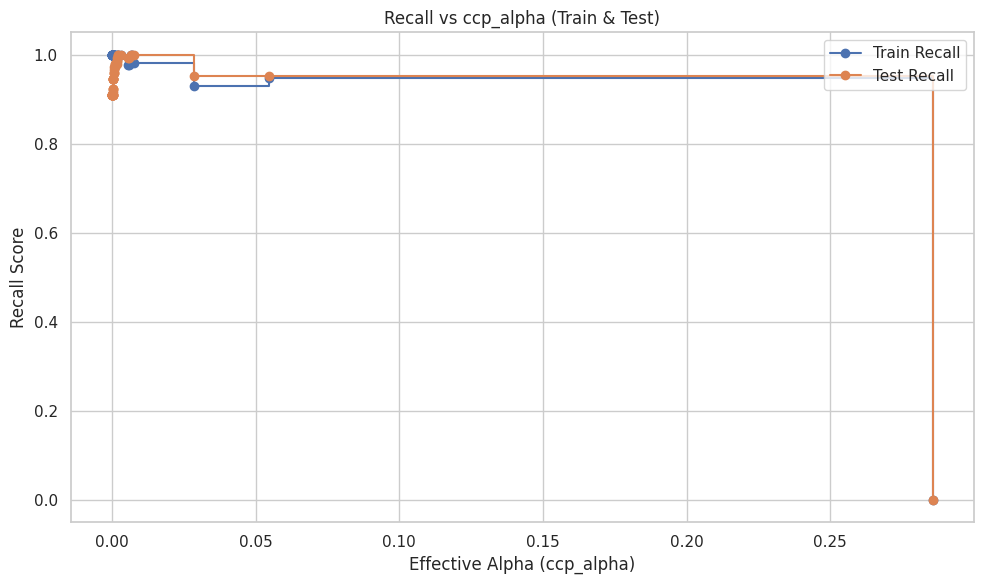

In [78]:
# Step 1: Train multiple models across ccp_alphas
clfs = []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=1, class_weight='balanced', ccp_alpha=alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)

# Step 2: Calculate recall scores
train_recalls = [recall_score(y_train, clf.predict(X_train)) for clf in clfs]
test_recalls = [recall_score(y_test, clf.predict(X_test)) for clf in clfs]

# Step 3: Plot recall vs alpha
plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, train_recalls, marker='o', label='Train Recall', drawstyle='steps-post')
plt.plot(ccp_alphas, test_recalls, marker='o', label='Test Recall', drawstyle='steps-post')
plt.xlabel('Effective Alpha (ccp_alpha)')
plt.ylabel('Recall Score')
plt.title('Recall vs ccp_alpha (Train & Test)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**Interpretation:**

- Train Recall:
  - Generally starts high and decreases as the tree is pruned (higher alpha → simpler model → fewer patterns captured).

- Test Recall:
  - Usually has a peak region where generalization is best — beyond that, recall drops because the tree is too simple.


- A point where test recall is high and close to train recall — that’s the sweet spot for pruning.
- Avoid areas where:
 - Train recall is very high, but test recall is low → overfitting
 - Both recalls drop sharply → underfitting

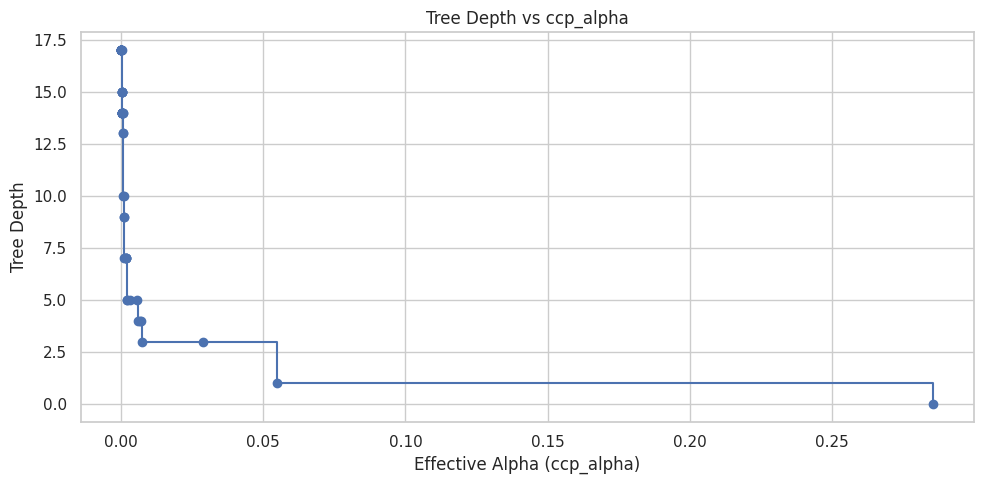

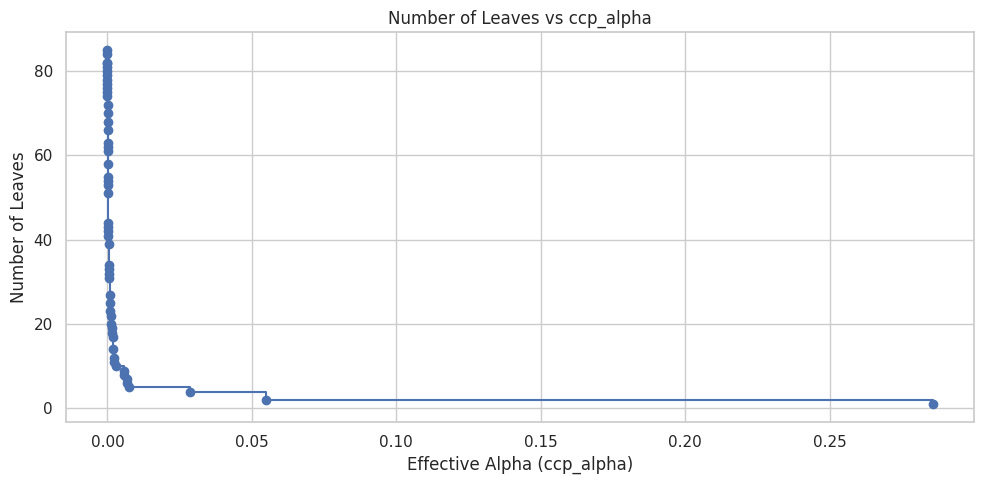

In [79]:
# Get tree depth and number of leaves for each pruned model
tree_depths = [clf.get_depth() for clf in clfs]
tree_leaves = [clf.get_n_leaves() for clf in clfs]

# Plot 1: Tree Depth vs ccp_alpha
plt.figure(figsize=(10, 5))
plt.plot(ccp_alphas, tree_depths, marker='o', drawstyle='steps-post')
plt.xlabel('Effective Alpha (ccp_alpha)')
plt.ylabel('Tree Depth')
plt.title('Tree Depth vs ccp_alpha')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 2: Number of Leaves vs ccp_alpha
plt.figure(figsize=(10, 5))
plt.plot(ccp_alphas, tree_leaves, marker='o', drawstyle='steps-post')
plt.xlabel('Effective Alpha (ccp_alpha)')
plt.ylabel('Number of Leaves')
plt.title('Number of Leaves vs ccp_alpha')
plt.grid(True)
plt.tight_layout()
plt.show()


**Plot 1: Tree Depth vs. ccp_alpha**

    Shows how the depth of the tree reduces as pruning strength increases.
    Useful to track model simplification.

**Plot 2: Number of Leaves vs. ccp_alpha**

    Reveals how final decision points shrink with higher pruning.
    Fewer leaves = simpler decisions = more interpretability.

**Creating best model**

,precision,recall,f1-score,support,roc_auc_score
0,1.000000,0.937316,0.967644,1356.000000,0.99463
1,0.628821,1.000000,0.772118,144.000000,0.99463
accuracy,0.943333,0.943333,0.943333,0.943333,0.99463
macro avg,0.814410,0.968658,0.869881,1500.000000,0.99463
weighted avg,0.964367,0.943333,0.948873,1500.000000,0.99463


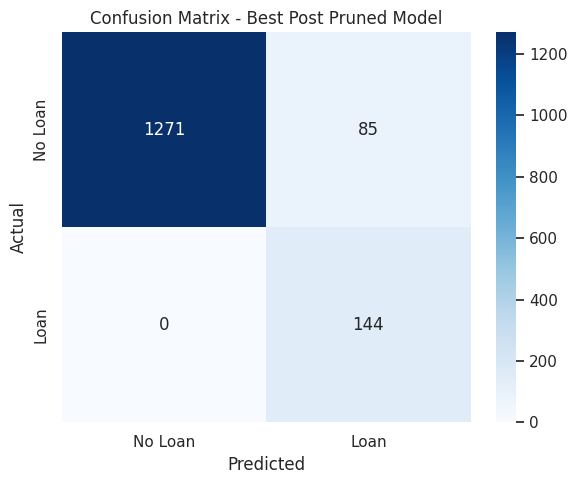

In [80]:
# Step 1: Train multiple models across ccp_alphas
clfs = []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=1, class_weight='balanced', ccp_alpha=alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)

# Step 2: Calculate recall scores and accuracy for training and testing sets
train_recalls = [recall_score(y_train, clf.predict(X_train)) for clf in clfs]
test_recalls = [recall_score(y_test, clf.predict(X_test)) for clf in clfs]

# Calculate test accuracy scores for model selection
train_scores = [accuracy_score(y_train, clf.predict(X_train)) for clf in clfs]
test_scores = [accuracy_score(y_test, clf.predict(X_test)) for clf in clfs]

# Step 3: Get the best model index (based on test recall or accuracy)
best_index = np.argmax(test_recalls)  # Or np.argmax(test_scores) based on recall or accuracy preference

# Step 4: Select the best pruned model based on the highest test recall
best_pruned_model = clfs[best_index]

# Step 5: Make predictions with the best pruned model
y_pred_pruned = best_pruned_model.predict(X_test)
y_proba_pruned = best_pruned_model.predict_proba(X_test)[:, 1]

# Step 6: Confusion Matrix
conf_matrix_pruned = confusion_matrix(y_test, y_pred_pruned)

# Step 7: Classification Report
class_report_pruned = classification_report(y_test, y_pred_pruned, output_dict=True)

# Step 8: ROC AUC Score
roc_auc_pruned = roc_auc_score(y_test, y_proba_pruned)

# Step 9: Display classification report using pandas DataFrame
report_pruned_df = pd.DataFrame(class_report_pruned).transpose()
report_pruned_df["roc_auc_score"] = roc_auc_pruned if "weighted avg" in report_pruned_df.index else None

# Display the classification report
display(report_pruned_df)

# Step 10: Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_pruned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Loan', 'Loan'],
            yticklabels=['No Loan', 'Loan'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Best Post Pruned Model')
plt.tight_layout()
plt.show()


## Model Performance Improvement

## Model Performance Comparison and Final Model Selection

In [81]:
# Define a function to evaluate the models and return the performance metrics
def evaluate_model_performance(models, X_train, X_test, y_train, y_test):
    results = []
    for model_name, model in models.items():
        # Train model and make predictions
        model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        # Calculate metrics for training and test sets
        accuracy_train = accuracy_score(y_train, y_pred_train)
        accuracy_test = accuracy_score(y_test, y_pred_test)

        recall_train = recall_score(y_train, y_pred_train)
        recall_test = recall_score(y_test, y_pred_test)

        precision_train = precision_score(y_train, y_pred_train)
        precision_test = precision_score(y_test, y_pred_test)

        f1_train = f1_score(y_train, y_pred_train)
        f1_test = f1_score(y_test, y_pred_test)

        # Store the results for each model
        results.append({
            'Model': model_name,
            'Train Accuracy': accuracy_train,
            'Test Accuracy': accuracy_test,
            'Train Recall': recall_train,
            'Test Recall': recall_test,
            'Train Precision': precision_train,
            'Test Precision': precision_test,
            'Train F1': f1_train,
            'Test F1': f1_test
        })

    return pd.DataFrame(results)

# Define the models you've built so far
models = {
    'Decision Tree (Default)': dt_default,
    'Decision Tree (Class-Weighted)': dt_weighted,
    'Decision Tree (Pre-Pruning)': dt_pruned,
    'Decision Tree (Post-Pruning)': best_pruned_model
}

# Evaluate the models' performance
performance_results = evaluate_model_performance(models, X_train, X_test, y_train, y_test)

# Display the performance results
display(performance_results)



,Model,Train Accuracy,Test Accuracy,Train Recall,Test Recall,Train Precision,Test Precision,Train F1,Test F1
0,Decision Tree (Default),1.000000,0.980667,1.000000,0.909722,1.000000,0.891156,1.000000,0.900344
1,Decision Tree (Class-Weighted),1.000000,0.980000,1.000000,0.902778,1.000000,0.890411,1.000000,0.896552
2,Decision Tree (Pre-Pruning),0.984000,0.988000,0.857143,0.909722,0.972973,0.963235,0.911392,0.935714
3,Decision Tree (Post-Pruning),0.950571,0.943333,1.000000,1.000000,0.660118,0.628821,0.795266,0.772118


## Actionable Insights and Business Recommendations


* What recommedations would you suggest to the bank?

Based on the analysis of the models, data, and performance metrics, here are some key recommendations for the AllLife Bank, to optimize their marketing campaigns and improve their loan offerings:

**1. Focus on High Recall for Loan Predictions**

 - Key Insight: Our models, particularly Post-Pruned, have shown that recall is crucial in ensuring that no potential loan customer is missed. The recall for loan buyers (Class 1) was very high (1.0) in some models, indicating that the model can successfully identify almost all loan buyers.

 Recommendation:

  - Prioritize models like Pre-Pruned or Post-Pruned that offer high recall. This ensures that more loan buyers are captured without missing any potential customers who might accept the loan.
  - Even though precision may not be as high for loan predictions, high recall ensures the bank does not miss any potential loan customers, which is critical for business growth.

**2. Consider Fine-Tuning the Precision for Loan Customers**

 - Key Insight: Although recall is high, the precision for the loan class (Class 1) is lower in some models (e.g., Post-Pruned model has precision around 63%). This means that some non-loan customers are being misclassified as loan buyers, which could lead to unnecessary marketing efforts.

 Recommendation:

  - Further optimize models (e.g., class-weighted models) to increase precision for loan buyers without sacrificing recall. This could help minimize marketing efforts targeted at non-loan customers, saving time and resources.

**3. Leverage the Insights from Pre-Pruning for Simplicity**

 - Key Insight: The Pre-Pruned model performs well with a balanced trade-off between recall, precision, and F1-score, with a test F1-score of 93.6%. It has a simpler, interpretable tree and avoids overfitting.

 Recommendation:

  - Use the Pre-Pruned model as a reliable, interpretable model for predicting potential loan buyers. This model's simplicity will make it easier for the marketing team to understand and act upon. It can be used in campaigns where interpretability is key, such as creating rules for targeted marketing.
  - This model can be particularly useful for segmenting customers and creating marketing strategies based on key features like income and credit card spending.

**4. Consider Expanding the Feature Set for Improved Prediction**

 - Key Insight: Features such as Income, CCAvg, Education, and Family played a major role in the model’s performance. However, certain features like Mortgage and CreditCard showed limited influence.

 Recommendation:

  - Experiment with additional features, such as customer behavior or transaction history, to further improve prediction accuracy. A better understanding of the relationship between spending habits and loan acceptance can be used to enhance segmentation.
  - For example, incorporating online banking behavior and customer engagement with bank offers could give more predictive power to the model.

**5. Optimize Campaign Targeting Using Customer Segmentation**

 - Key Insight: The models identified significant predictors for loan acceptance, including Income and CCAvg. These features can be used to target specific customer segments.

 Recommendation:

  - Use the best-performing models to segment customers into groups with high probability of accepting a loan. For instance:
    - High-income and high credit card spenders: These customers are more likely to accept loans and should be a primary focus for marketing.
    - Mid-income customers with moderate credit card spending could be offered smaller loans with attractive interest rates to boost conversion.
    - Low-income customers might need more financial education or lower-risk loan products, but should not be excluded outright.
  - Run targeted campaigns for each of these segments with personalized messaging based on the customer’s attributes. For example, promote low-interest loans to high spenders and financial education programs to those less engaged with banking products.

**6. Monitor Performance Regularly and Update the Model**

 - Key Insight: The models performed well on the training and testing datasets, but the bank should regularly monitor the model's performance on new data.

 Recommendation:

  - Set up a feedback loop to regularly monitor and retrain the models as customer behavior evolves and as new data is collected.
  - Fine-tune the models periodically, especially for features related to economic shifts, marketing trends, and customer interaction with the bank.

**FINAL SUMMARY:**

In summary, the best post-pruned model and pre-pruned model provide a strong foundation for targeted marketing campaigns, focusing on customer recall and cost-effectiveness. The class-weighted model can help fine-tune predictions for specific customer segments by balancing precision and recall.

___